# 📋 Loan Interest-Rate Regression — Cheat Sheet
A quick-reference companion to the bank loan pricing project. Organized by workflow
stage, with runnable mini-examples against `bank_loans_sim.csv` so every snippet is
demonstrably correct — copy, paste, adapt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv("bank_loans_sim.csv")
df.shape


(5214, 14)

---
## 1. Loading & First Look

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_id            5214 non-null   int64  
 1   loan_id           5214 non-null   str    
 2   credit_score      5214 non-null   int64  
 3   annual_income     5214 non-null   float64
 4   employment_years  5214 non-null   float64
 5   home_ownership    5214 non-null   str    
 6   loan_purpose      5214 non-null   str    
 7   loan_amount       5214 non-null   float64
 8   term_months       5214 non-null   int64  
 9   verified_income   5214 non-null   str    
 10  delinq_2yr        5214 non-null   int64  
 11  dti               5214 non-null   float64
 12  interest_rate     5214 non-null   float64
 13  loan_status       5214 non-null   str    
dtypes: float64(5), int64(4), str(5)
memory usage: 570.4 KB


In [3]:
df.describe(include='all').T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
row_id,5214.0,NaN,NaN,NaN,2607.5,1505.296482,1.0,1304.25,2607.5,3910.75,5214.0
loan_id,5214,5200,LN100387,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_score,5214.0,NaN,NaN,NaN,667.942846,133.489963,0.0,640.0,687.0,730.0,850.0
annual_income,5214.0,NaN,NaN,NaN,56412.157269,31460.294212,-1.0,37500.0,51700.0,71600.0,331600.0
employment_years,5214.0,NaN,NaN,NaN,10.182605,18.660871,0.1,3.2,5.6,9.3,99.0
home_ownership,5214,4,MORTGAGE,2367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_purpose,5214,7,debt_consolidation,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,5214.0,NaN,NaN,NaN,11475.738397,6635.425983,1500.0,6800.0,9800.0,14300.0,40000.0
term_months,5214.0,NaN,NaN,NaN,44.027618,11.324521,36.0,36.0,36.0,60.0,60.0
verified_income,5214,3,Source Verified,2121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Finding Duplicate Records

Administrative/transactional data (loan applications, orders, claims) often contains
accidental duplicate submissions.

In [4]:
dup_cols = [c for c in df.columns if c != 'row_id']  # ignore the surrogate key
n_dupes = df.duplicated(subset=dup_cols).sum()
print(f"{n_dupes} exact duplicate rows (ignoring the ID column)")

df_dedup = df.drop_duplicates(subset=dup_cols)


14 exact duplicate rows (ignoring the ID column)


---
## 3. Handling Sentinel / Missing Codes

| Symptom | Likely meaning |
|---|---|
| A score/age column has an impossible minimum (0, -1) | "Not available" sentinel |
| A count/years column has an impossible maximum (99, 999) | "Not applicable / unknown" sentinel |
| An outcome column has a value wildly outside its normal range | Data-entry glitch, treat as missing |

In [5]:
print(sorted(df['credit_score'].unique())[:3])       # -> 0 stands out (real FICO starts at 300)
print(sorted(df['employment_years'].unique())[-3:])  # -> 99 stands out
print(df['interest_rate'].max())                     # -> 999 stands out


[np.int64(0), np.int64(453), np.int64(486)]
[np.float64(37.6), np.float64(40.0), np.float64(99.0)]
999.0


In [6]:
clean = df_dedup.copy()
clean['credit_score'] = clean['credit_score'].replace(0, np.nan)
clean['annual_income'] = clean['annual_income'].replace(-1, np.nan)
clean['employment_years'] = clean['employment_years'].replace(99, np.nan)
clean['interest_rate'] = clean['interest_rate'].replace(999, np.nan)
clean[['credit_score', 'annual_income', 'employment_years', 'interest_rate']].isna().sum()


credit_score        156
annual_income       312
employment_years    208
interest_rate         5
dtype: int64

---
## 4. Structural vs. Random Zeros — the Cross-Tab Trick

Before treating a suspicious `0` as a real value, cross-tabulate it against a related
column's missingness.

In [7]:
pd.crosstab(clean['annual_income'].isna(), clean['dti'] == 0)


dti,False,True
annual_income,,
False,4887,1
True,0,312


If almost every `dti == 0` lines up with a missing `annual_income`, the zero is a
**computation artifact** (no income → no ratio → system defaults to 0), not a genuine
"no debt" signal. Null it out rather than modeling it as real.

In [8]:
zero_is_structural = clean['annual_income'].isna() & (clean['dti'] == 0)
clean.loc[zero_is_structural, 'dti'] = np.nan


---
## 5. Filtering to a Modelable Analytic Sample

In [9]:
required_cols = ['credit_score', 'annual_income', 'employment_years', 'dti', 'interest_rate']
analysis = clean.dropna(subset=required_cols).copy()
print(f"{len(clean)} -> {len(analysis)} rows after requiring complete data on key fields")


5200 -> 4546 rows after requiring complete data on key fields


---
## 6. Checking Skew & Log-Transforming Predictors

Note: you can log-transform a **predictor**, the **outcome**, or both — decide based on
each variable's own distribution and role, not by habit.

In [10]:
for col in ['loan_amount', 'annual_income']:
    print(f"{col}: skew = {analysis[col].skew():.2f}")

analysis['log_loan_amount'] = np.log(analysis['loan_amount'])
analysis['log_annual_income'] = np.log(analysis['annual_income'])
print('log_loan_amount skew:  ', analysis['log_loan_amount'].skew().round(2))
print('log_annual_income skew:', analysis['log_annual_income'].skew().round(2))


loan_amount: skew = 1.51
annual_income: skew = 1.62
log_loan_amount skew:   -0.0
log_annual_income skew: 0.02


**Rule of thumb:** don't automatically log-transform a bounded percentage/rate outcome (like `interest_rate`, 0-100) — log transforms are for strictly positive, right-skewed, effectively unbounded quantities (income, price, loan size, wait times, counts).

---
## 7. Outlier Detection (IQR / Boxplot Method)

In [11]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

lo, hi = iqr_bounds(analysis['dti'])
outliers = (analysis['dti'] < lo) | (analysis['dti'] > hi)
print(f"Bounds: [{lo:.1f}, {hi:.1f}]  ->  {outliers.sum()} outliers")
clean_final = analysis[~outliers]


Bounds: [-11.9, 32.6]  ->  272 outliers


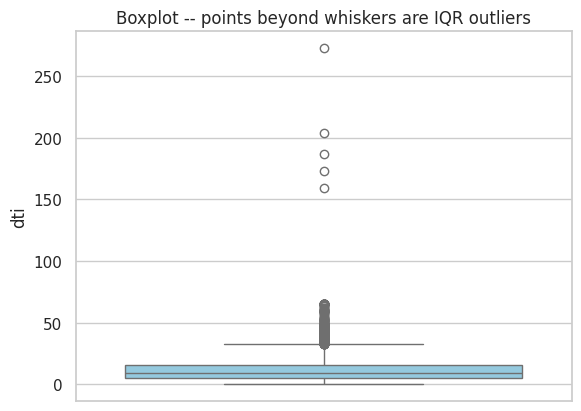

In [12]:
sns.boxplot(y=analysis['dti'], color='skyblue')
plt.title('Boxplot -- points beyond whiskers are IQR outliers')
plt.show()


---
## 8. Train/Test Split

In [13]:
train, test = train_test_split(clean_final, test_size=0.2, random_state=42)
print(len(train), len(test))


3419 855


---
## 9. Fitting Models with Mixed Predictor Types

In [14]:
formula = ("interest_rate ~ credit_score + dti + log_loan_amount + log_annual_income "
           "+ employment_years + delinq_2yr + C(term_months) + C(loan_purpose) "
           "+ C(verified_income) + C(home_ownership)")
model = smf.ols(formula, data=train).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     349.3
Date:                Sat, 22 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:59:16   Log-Likelihood:                -6064.1
No. Observations:                3419   AIC:                         1.217e+04
Df Residuals:                    3400   BIC:                         1.228e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

| Task | Syntax |
|---|---|
| Numeric predictor | just the column name: `credit_score` |
| Categorical predictor (any dtype) | wrap in `C(...)`: `C(loan_purpose)` |
| Integer column that's really categorical | `C(term_months)` — e.g. loan term codes 36/60 |
| Interaction term | `credit_score:dti` (interaction only) or `credit_score*dti` (both mains + interaction) |
| Polynomial term | precompute a column (`x**2`) — cleaner than `I(x**2)` for repeated reuse |

---
## 10. Model Fit Statistics & Residual Diagnostics

In [15]:
print('R-squared:      ', model.rsquared)
print('Adj. R-squared: ', model.rsquared_adj)
print('RSE:            ', np.sqrt(model.mse_resid))


R-squared:       0.6490438112201818
Adj. R-squared:  0.6471858078678181
RSE:             1.4297546336173665


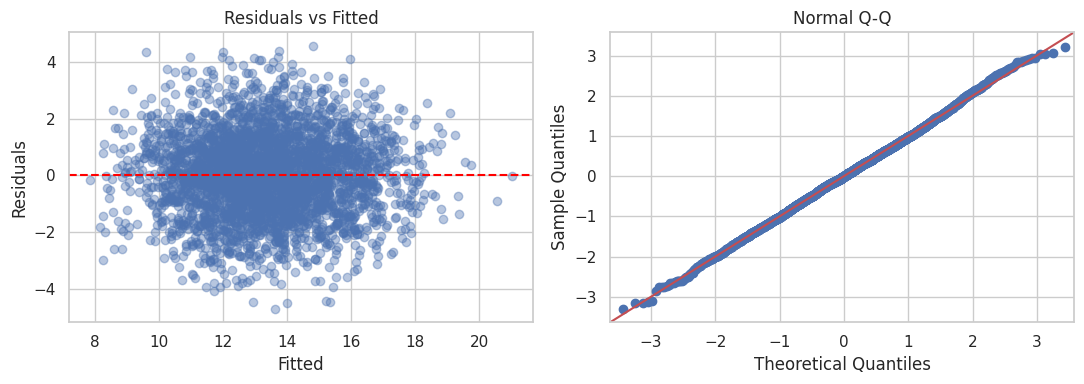

In [16]:
fitted, resid = model.fittedvalues, model.resid
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(fitted, resid, alpha=0.4)
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Fitted', ylabel='Residuals', title='Residuals vs Fitted')
sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normal Q-Q')
plt.tight_layout(); plt.show()


---
## 11. Multicollinearity (VIF) with Dummy-Encoded Categoricals

In [17]:
X = pd.get_dummies(
    train[['credit_score', 'dti', 'log_loan_amount', 'log_annual_income',
           'employment_years', 'delinq_2yr', 'term_months', 'loan_purpose',
           'verified_income', 'home_ownership']],
    drop_first=True
)
X = sm.add_constant(X.astype(float))
pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).query("variable != 'const'").sort_values('VIF', ascending=False)


,variable,VIF
8,loan_purpose_debt_consolidation,1.695678
15,verified_income_Verified,1.598856
14,verified_income_Source Verified,1.598327
9,loan_purpose_home_improvement,1.363825
10,loan_purpose_major_purchase,1.271692
12,loan_purpose_other,1.262726
4,log_annual_income,1.247070
2,dti,1.245727
13,loan_purpose_small_business,1.237769
11,loan_purpose_medical,1.163355


---
## 12. Nested Model Comparison

In [18]:
model_simple = smf.ols('interest_rate ~ credit_score', data=train).fit()
anova_lm(model_simple, model)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,3417.0,13736.281972,0.0,NaN,NaN,NaN
1,3400.0,6950.274262,17.0,6786.00771,195.273092,0.0


---
## 13. Predicting & Evaluating

In [19]:
test = test.copy()
test['pred'] = model.predict(test)
print('Test R2:  ', r2_score(test['interest_rate'], test['pred']))
print('Test RMSE:', np.sqrt(mean_squared_error(test['interest_rate'], test['pred'])))

baseline = np.full(len(test), train['interest_rate'].mean())
print('Baseline RMSE:', np.sqrt(mean_squared_error(test['interest_rate'], baseline)))


Test R2:   0.6788396015957994
Test RMSE: 1.3479475509097765
Baseline RMSE: 2.3803783601487103


---
## 14. Interpreting Coefficients (Untransformed Outcome)

Unlike the log-income project, `interest_rate` here is used **untransformed**, so
coefficients have a direct, simple reading:

| Model form | Coefficient meaning |
|---|---|
| `interest_rate ~ credit_score` | +1 credit-score point → β percentage-point change in rate |
| `interest_rate ~ log_loan_amount` | +1% change in loan amount → ~(β/100) percentage-point change in rate |
| `interest_rate ~ C(loan_purpose)` | each purpose's β is the rate difference vs. the left-out reference purpose |
| p-value < 0.05 | reject "no linear relationship" null at the 5% level |
| 95% CI excludes 0 | consistent with a statistically significant effect |

In [20]:
coef, pval, ci = model.params['credit_score'], model.pvalues['credit_score'], model.conf_int().loc['credit_score']
print(f"beta = {coef:.4f}, p = {pval:.2e}, 95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")


beta = -0.0206, p = 0.00e+00, 95% CI = [-0.0213, -0.0198]


---
## 15. Common Pitfalls Checklist

- [ ] Checked for exact duplicate rows before anything else
- [ ] Checked `.describe()` / `.unique()` for sentinel missing-value codes
- [ ] Cross-tabbed suspicious zeros against a related column's missingness before
      trusting them as real
- [ ] Decided per-variable whether to log-transform (predictor vs. outcome; bounded vs.
      unbounded quantities)
- [ ] Held out a test set before evaluating predictive performance
- [ ] Checked residual plots, not just R²
- [ ] Used adjusted R² (not raw R²) when comparing models with different predictor counts
- [ ] Checked VIF before trusting individual coefficients in a multiple regression
- [ ] Stated the correct reference category when interpreting categorical coefficients
- [ ] Did NOT claim causation from an observational/administrative regression coefficient
- [ ] Kept post-outcome variables (like `loan_status` here) out of a pre-outcome pricing model